In [ ]:
from langchain_groq import ChatGroq
import os
os.getenv('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = ''

/Users/roraghav/Agentic-AI- course/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

#Recap- Prompting
#Types
# Zero shot prompt
#Few Shot Prompt
''' eg.
" Text: I love this phone // Sentiment:Positive
  Text: The battery dies in an hour. // Sentiment:negative
  Text: Its okay, nothing special. // Sentiment:"   '''
# Context
#Constraints


# Agentic AI- Prompt
'''
1. Mission statement
Trational prompting:"Summarize the meeting transcript"
Agentic AI: "continuously monitor meeting, detect action items,and trigger follow up actions like jira ticket and notify people"

2. Guardrails and boundary condition

3. Orchestrating Mutistep reasoning- ReAct ( Reason + Act)
Dont act immediately
First plan what to do
then check if plan is safe or correct
only exceute
eg. "Before performing a task, draft a 3-step plan.
 Review this plan for potential security risk.
 only if no risk are found, then execute the steps."

Agent-->
 Think-> create a plan
 Double-check-> looks for problem (like security issues)
 Act-> only if everything looks safe

4. Dynamic context and memory management

5. MultiAgent Coordination

'''

In [ ]:
'''
LangChain-   workflow   -llm_obj.invoke(userquery) - linear-> step1-> step2-> step 3
             implicit state
LangGraph -              -cyclic- loops and condition
                          - explicit state

LangChain-> Direct call-> input-> output
LangGraph->
Wrap call inside a node
pass everything through a state
Build a graph workflow

1. Define state - schema
2. create LLm object
3. define node- wrap this LLm
4. build graph
5. Define entry + exit
6. compile graph
7. Run
'''

'''
LangChain-   workflow   -llm_obj.invoke(userquery) - linear-> step1-> step2-> step 3
             implicit state
LangGraph -              -cyclic- loops and condition
                          - explicit state

LangChain-> Direct call-> input-> output
LangGraph->
Wrap call inside a node
pass everything through a state
Build a graph workflow

1. Define state - schema
2. create LLm object
3. define node- wrap this LLm
4. build graph
5. Define entry + exit
6. compile graph
7. Run
'''

In [6]:
from langgraph.graph import StateGraph
from typing import TypedDict

#1. Define state - schema
class State(TypedDict):
    input: str
    output: str

# 2. create LLm object
llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

# 3. define node- wrap this LLm
def call_llm(state: State):
    response = llm_obj.invoke(state['input'])
    return {"output": response.content}

# 4. build graph
graph = StateGraph(State)
graph.add_node("llm_node",call_llm)

# 5. Define entry + exit
graph.set_entry_point("llm_node")
graph.set_finish_point("llm_node")

# 6. compile graph
app = graph.compile()

# 7. Run
result = app.invoke({"input":"UserQuery"})
print(result["output"])


It seems like you're trying to start a conversation. I can respond in various ways. Here are a few options:

1. **General Conversation**: We can talk about any topic you're interested in. What's on your mind?
2. **Ask a Question**: If you have a specific question, feel free to ask. I'll do my best to provide a helpful answer.
3. **Play a Game**: We can play a game like Hangman, 20 Questions, or Word Chain.
4. **Get Information**: If you need information on a particular topic, I can provide you with some knowledge.

Which option sounds appealing to you, or do you have something else in mind?


In [8]:
#Lang graph {"text": 'start->step1->step2'}
# 1. Define state - schema
class State(dict):
    text: str

# 2. Define node1
def node1(state):
    state["text"] = state["text"] + "--> step1"
    return state

# 3. Define node2
def node2(state):
    state["text"] = state["text"] + "--> step2"
    return state

# 4. build graph
builder = StateGraph(State)
builder.add_node("step1",node1)
builder.add_node("step2",node2)

# 5. Define entry + edge
builder.set_entry_point("step1")
builder.add_edge("step1","step2")

# 6. compile graph
app = builder.compile()

# 7. Run
result = app.invoke({"text": "start"})
print(result["text"])

start--> step1--> step2


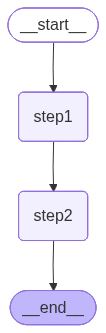

In [ ]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

'''
Conditional LangGraph

if condition:
   go_here
else:
  go_there


  (start)
   |
  router Node
   |
|----------------|
success node    error_node

decisio appens after router node

'''

In [11]:
#State Definition
class State(dict):
    text: str
    result: str

#Router Node
def router_node(state):
    return state

#Router Logic
def router_decision(state):
    if "error" in state["text"]:
        return "error_node"
    return "success_node"

def success_node(state):
    state["result"] = "Success Path"
    return state

def error_node(state):
    state["result"] = "Error Node"
    return state

#building a graph
builder = StateGraph(State)
builder.add_node("router",router_node)
builder.add_node("success_node",success_node)
builder.add_node("error_node",error_node)

builder.set_entry_point("router")

#condition adges using routing decision function
builder.add_conditional_edges(
    "router",
    router_decision,
    {
        "success_node" : "success_node",
        "error_node" : "error_node"
    }
)

#compiling
graph = builder.compile()

#run
print(graph.invoke({"text":"hello"}))
print(graph.invoke({"text":"error found"}))


    
    


{'text': 'hello', 'result': 'Success Path'}
{'text': 'error found', 'result': 'Error Node'}


'''
Case1 :
print(graph.invoke({"text":"hello"}))

|
Start-> router
Runrouter node-> state unchanged
Run route decision("hello")
--> return "success_node
     |---Go To success_node
      +=============> {'text': 'hello', 'result': 'Success path'}

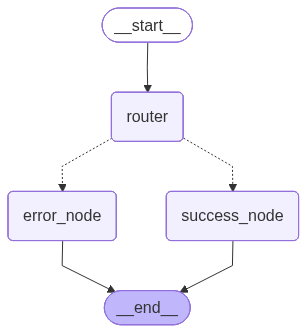

In [13]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

'''
Loop / retry Mechanism

increment
|
check
  |
|--------|
retry    done
 |             |
 increment         end
Reflection agent(Think-> retry->improve) 

In [16]:
#state definition

class State(dict):
    count: int
    message: str

def check(state):
    if ( state["count"] >= 3):
        return "done"
    return "retry"

def increment(state):
    state["count"] += 1
    return state

def done(state):
    state["message"] = "Finished"
    return state

#graph
builder = StateGraph(State)
builder.add_node("increment",increment)
builder.add_node("done",done)

#setting points
builder.set_entry_point("increment")
builder.add_conditional_edges("increment",
                              check,
                              {
                                  "retry": "increment",
                                  "done" : "done"
                              })

graph= builder.compile()

print(graph.invoke({"count":0}))


{'count': 3, 'message': 'Finished'}


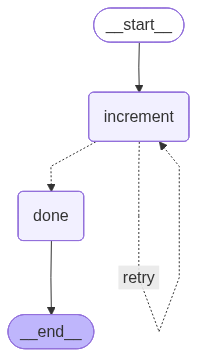

In [17]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

# UseCase
'''
EndUser--> Ask Query---> Agent1 --> pass this query to Agent2 --> Agent2 -- connect to LLm .
then LLM will response to Agent2--> Agent2 send response to EndUser

'''

In [24]:
from langchain_groq import ChatGroq
import os

llm = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))

# Define State Schema
class State(dict):
  messages: list

# Define 2 Nodes

def ask_topic(state):
    '''Ask Topic from User'''
    topic= input('Enter the Topic Name')
    state['messages']=[f"Summarize {topic} in one short paragraph"]
    return state

def summarize(state):
    prompt= state["messages"][0]
    response= llm.invoke(prompt)
    print("AI Summary: ", response.content)
    return state


graph= StateGraph(State)
graph.add_node("ask_topic",ask_topic)
graph.add_node("summarize",summarize)

graph.set_entry_point("ask_topic")
graph.add_edge("ask_topic","summarize")
#graph.set_finish_point("summarize")

app = graph.compile()
app.invoke({})


AI Summary:  A cat is a small, carnivorous mammal belonging to the family Felidae. They have a slender body, usually furry, with retractable claws and sharp teeth. Cats are known for their agility, quick reflexes, and hunting abilities, making them skilled predators. They are often domesticated as pets, requiring regular care and attention, and are known for their affectionate and playful personalities.


{'messages': ['Summarize cat in one short paragraph']}

#LangGraph
# llm model- node
# How to combine with tools

#depricated method
from langchain.tools import tool
from langchain.agents import create_agent

@tool
def calculator(expression: str) -> str:
    """Evaluates a simple mathematical expression."""
    return str(eval(expression))  # only for trusted input

agent = create_agent(model=llm, tools=[calculator])

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What is 2*3?"}]}
)

print(result["messages"][-1].content)

In [32]:
from langchain_core.tools import tool

# Tool
@tool
def calculator(expression:str)->str:
    '''Evaluates simple mathematical operation 2*3  '''
    return str(eval(expression))


# State Defn

class State(dict):
  input: str
  output: str

# Node ( LLM + Tool Logic)

def node(state):
  user_input = state["input"]

  if "calculate" in user_input or "*" in user_input:
    result=calculator.invoke("23 * 47")
    return {"output": f"Tool result:{result}"}
  response= llm.invoke(user_input)
  return {"output": response.content}


graph = StateGraph(State)
graph.add_node("agent",node)

graph.set_entry_point("agent")
graph.set_finish_point("agent")

app= graph.compile()

# Run
result=app.invoke({"input":"What is 23 * 47"})
print(result["output"])

Tool result:1081


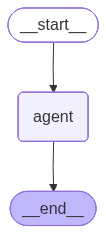

In [31]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

#Task
#====
'''
1. Meeting Transcripts --> Structured Notes  (transcript.txt)

===== Structured Meeting Notes
Key Discussion Points:
-...
-...
Decision Made:

Action Items:
...

2.  Convert long report--> short decision- (report.txt)

3. LangGraph
      Python Execution Agent
      If user ask logic-> python code dynamically-> result returned.
      exec()

  Query: Run python code to calculate sum from 1 to 100

4.  create a single node->
      llm->
      prompt=""" Decide best tool for user query.

      Options:
      calc-> math
      Python-> python code
      llm-> general question

      Query:{query}

      Answer in one qord: calc OR python OR llm

      """

    # if elseif else
    decision = llm.invoke(prompt)
    if "python" in decision:
        python.invoke(query
    else if "calc " in decision:
        calculator.invoke(query)
    else
        llm.invoke(query)


'''

In [35]:
#1. Meeting Transcripts --> Structured Notes  (transcript.txt)

from langchain_groq import ChatGroq
from langchain_core.prompts import  ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os


# Sample Transcript
transcript="""
John: We need to finalize the product launch timeline.
Sara: Marketing campaign will start next Monday.
Mike: Development is 90% complete, but testing is pending.
John: Let's aim for release by end of this month.
Sara: Agreed. I'll prepare campaign materials.
Mike: I'll complete testing by next week.
"""

# Prompt Template
prompt=ChatPromptTemplate.from_template("""

Summarize the meeting Transcript.

Include:
- Key Discussion
- Decisions Made
- Action Items

Transcript:
{text}
""")
# Output Parser
parser= StrOutputParser()

# Chain
chain= prompt | llm | parser

# Execute the chain

result=chain.invoke({"text":transcript})
print("================STRUCTURED MEETING NOTES================\n")
print(result)

================STRUCTURED MEETING NOTES================

**Meeting Summary**

**Key Discussion:** 
- The team discussed the product launch timeline, focusing on development, testing, and marketing readiness.

**Decisions Made:**
- The product launch will aim for the end of this month.
- Sara will prepare marketing campaign materials.

**Action Items:**
- Mike: Complete testing by next week.
- Sara: Prepare marketing campaign materials.
- John: Will monitor the progress towards the end of the month release goal.


In [36]:
#2.  Convert long report--> short decision- (report.txt)

from langchain_groq import ChatGroq
from langchain_core.prompts import  ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os


# Output Parser
parser= StrOutputParser()

# Input-Long Bussiness Report
long_text="""
Quarterly Business Report – Q2 2025

The organization recorded strong financial performance in Q2 2025, with total revenue
reaching $12.5 million, reflecting a 25% increase compared to the previous quarter.
This growth was primarily driven by increased adoption of the company’s AI-driven analytics
platform across enterprise clients in the retail and healthcare sectors.

Customer acquisition grew by 18%, while customer retention improved from 78% to 90%,
indicating higher satisfaction and product stickiness. The introduction of automated
onboarding workflows reduced customer setup time by 35%, contributing to improved user experience.

Operational efficiency also improved significantly. The implementation of internal automation
tools reduced manual workloads in data processing by 40%, resulting in a 12% decrease in
operational costs. However, infrastructure-related challenges emerged due to rapid scaling,
leading to intermittent system downtimes affecting approximately 3% of users during peak hours.

The technology team has proposed a migration to a more scalable cloud-native architecture
to address these issues. This initiative is expected to increase system reliability by 50%
and reduce downtime incidents in the next quarter.

From a market perspective, competition has intensified, with two new entrants offering
similar AI capabilities at lower pricing tiers. In response, the company plans to
differentiate through enhanced features, improved customer support, and strategic partnerships.

Looking ahead, the forecast for Q3 remains optimistic. Revenue is projected to grow by
an additional 15–20%, supported by pipeline deals and expansion into new geographic markets.
Key priorities include infrastructure scaling, feature innovation, and maintaining high
customer satisfaction levels.
"""

# Prompt Template
ChatPromptTemplate.from_template("""

Summarize the following text into a executive sunnary.

Focus on:
-Key Insights
-Bussiness Impack
-Final conclusion

Text:
{text}
""")

# Build chain
chain= prompt | llm| parser
# Run
result= chain.invoke({"text":long_text})
print("=============Executive Bussiness Summary============\n")
print(result)



=============Executive Bussiness Summary============

**Meeting Transcript Summary**

**Key Discussion:**

- Financial performance in Q2 2025 showed a 25% increase in total revenue to $12.5 million.
- Customer acquisition grew by 18%, customer retention improved from 78% to 90%, and automated onboarding workflows reduced customer setup time by 35%.
- Operational efficiency improved with internal automation tools reducing manual workloads in data processing by 40%, resulting in a 12% decrease in operational costs.
- Infrastructure-related challenges emerged due to rapid scaling, leading to intermittent system downtimes affecting approximately 3% of users during peak hours.
- Competition has intensified with two new entrants offering similar AI capabilities at lower pricing tiers.

**Decisions Made:**

- The company plans to differentiate through enhanced features, improved customer support, and strategic partnerships.
- A migration to a more scalable cloud-native architecture is propose

In [37]:
'''
3. LangGraph
      Python Execution Agent
      If user ask logic-> python code dynamically-> result returned.
      exec()

  Query: Run python code to calculate sum from 1 to 100
'''

# State
class State(dict):
  input : str
  output : str

 #tool
@tool
def python_exec(code:str) :
  ''' Execute Python Code '''
  local_vars={}
  exec(code,{},local_vars)
  return str(local_vars)

def agent_node(state):
  query=state["input"]
  if "python" in query.lower()  or "code" in query.lower():
    code="""
result= sum([i for i in range(1,100)])
    """
    result=python_exec.invoke(code)
  else:
    result=llm.invoke(query).content
  return {"output":result}

#Test
graph= StateGraph(State)
graph.add_node("agent",agent_node)
graph.set_entry_point("agent")
graph.set_finish_point("agent")
app= graph.compile()

print(app.invoke({"input":"Run python code to calculate sum from 1 to 100"}))

{'input': 'Run python code to calculate sum from 1 to 100', 'output': "{'result': 4950}"}


In [43]:
'''
4.  create a single node->
      llm->
      prompt=""" Decide best tool for user query.

      Options:
      calc-> math
      Python-> python code
      llm-> general question

      Query:{query}

      Answer in one qord: calc OR python OR llm

'''

# State
class State(dict):
  input: str
  output: str

# Tools
@tool
def calculator(expression:str):
  ''' Evaluates Math Calculations'''
  try:
    print("calc tool")
    return str(eval(expression))
  except Exception as e:
    return f"Calc Error : {str(e)}"

@tool
def python_exec(code:str) :
  ''' Execute Python Code '''
  try:
    print("python tool")
    local_vars={}
    exec(code,{},local_vars)
    return str(local_vars)
  except Exception as e:
      return f"Python Error: {str(e)}"

# Agent Node- LLM decides tool

def agent_node(state):
  query=state["input"]
  decision_prompt=""" Decide best tool for user query.

      Options:
      -calc-> for mathematical calculations
      -python-> for python code execution
      -llm-> for general question

      Query:{query}

      Answer in one word: calc OR python OR llm

    """
  decision=llm.invoke(decision_prompt).content.lower().strip()

  if "calc" in decision:
      result=calculator.invoke(query)
  elif "python" in decision:
      code_prompt="""
Convert the following request to Python code.
Return executable code.

Request: {query}
    """
      code=llm.invoke(code_prompt).content

      result=python_exec.invoke(code)
  else:
     result=llm.invoke(query).content
  return {"output":result}


#Build Graph
graph= StateGraph(State)
graph.add_node("agent",agent_node)
graph.set_entry_point("agent")
graph.set_finish_point("agent")
app= graph.compile()

# Run
print("--------------Test1 : Math Calculation-----------")
print(app.invoke({"input":"100 / 4 + 40"}))

print("--------------Test2 : Python Code Execution-------")
print(app.invoke({"input":"Write a python code to calculate factorial of 5"}))

print("--------------Test3: General LLm Query---------------")
print(app.invoke({"input":"What is the capital of India?"}))

--------------Test1 : Math Calculation-----------
calc tool
{'input': '100 / 4 + 40', 'output': '65.0'}
--------------Test2 : Python Code Execution-------
{'input': 'Write a python code to calculate factorial of 5', 'output': '**Calculating Factorial of 5 in Python**\n=====================================================\n\nHere\'s a simple Python function that uses recursion to calculate the factorial of a number. In this case, we\'ll calculate the factorial of 5.\n\n```python\ndef factorial(n):\n    """\n    Calculate the factorial of a number.\n\n    Args:\n        n (int): The number to calculate the factorial of.\n\n    Returns:\n        int: The factorial of the number.\n\n    Raises:\n        ValueError: If the input number is negative.\n    """\n    if n < 0:\n        raise ValueError("Factorial is not defined for negative numbers.")\n    elif n == 0 or n == 1:\n        return 1\n    else:\n        return n * factorial(n-1)\n\n# Calculate the factorial of 5\nresult = factorial(

#ReAct= Reasoning + Acting
# Thought-> Act -> Observation->Repeat
'''
"What is 20 * 100?"
Thought:  whether I should multiply.
Action: calculator
Action Input:
--------------// Iteration Thought-> Act->
|
Tool
|
Observation :200
---------------------// Iteration
Thought: I have incorrect result. i need calculate again
Action: calculator
Action Input:
--------------// Iteration Thought-> Act->
|
Tool
|
Observation :20000
---------------------// Iteration
Thought: Is Now the final answer

'''


In [55]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
 
# State
class State(dict):
  input: str
  scratchpad: str
  output: str

# Tools
# Calculator
@tool
def calculator(expression:str):
  ''' Evaluates Math Calculations'''
  try:
    return str(eval(expression))
  except Exception as e:
    return f"Calc Error : {str(e)}"

# Agent Node
def agent(state):
  prompt= f"""
   You are a ReAct agent.

   You  can use:
   -calculator

   Use this format:

   Thought: what to do
   Action: calculate or finish
   Action Input: input

   Previous_step: 
   {state.get("scratchpad","")}

    Question: {state["input"]}

  """
  response= llm.invoke(prompt).content
  state["scratchpad"] += "\n"+response
  print(state["scratchpad"] )
  return state

def route(state):
  text = state["scratchpad"]

  if "Action: calculate" in text:
    return "tool"
  elif "Action: finish" in text:
    return "finish"
  else:
    return "agent"
  
def tool_node(state):
  last_line = state["scratchpad"].split("\n")[-1]

  if "Action Input" in last_line:
    expr = last_line.split("Action Input: ")[-1].strip()
  else:
    expr = "0"

  result = calculator(expr)

  state["scratchpad"] += f"Observation:{result}"
  return state

def final(state):
  state["output"] = state["scratchpad"]
  return state

#build graph
builder = StateGraph(State)
builder.add_node("agent",agent)
builder.add_node("tool",tool_node)
builder.add_node("final",final)

builder.set_entry_point("agent")
builder.add_conditional_edges(
  "agent",
  route,
  {
    "tool":"tool",
    "agent":"agent",
    "end":"final"
  }
)
builder.add_edge("tool","agent")

app = builder.compile()

print(app.invoke({"input":"What is 20 * 100?","scratchpad":""}))





Thought: Calculate the product of 20 and 100.
Action: Use the calculator to find the result.
Action Input: 20 * 100
Previous_step: 

Answer: The result of 20 * 100 is 2000.

Thought: Calculate the product of 20 and 100.
Action: Use the calculator to find the result.
Action Input: 20 * 100
Previous_step: 

Answer: The result of 20 * 100 is 2000.
Thought: Use the calculator to find the product of 20 and 100.
Action: Calculate the result.
Action Input: 20 * 100
Previous_step: 

Answer: The result of 20 * 100 is 2000.

Thought: Calculate the product of 20 and 100.
Action: Use the calculator to find the result.
Action Input: 20 * 100
Previous_step: 

Answer: The result of 20 * 100 is 2000.
Thought: Use the calculator to find the product of 20 and 100.
Action: Calculate the result.
Action Input: 20 * 100
Previous_step: 

Answer: The result of 20 * 100 is 2000.
Thought: Use the calculator to find the product of 20 and 100.
Action: Calculate the result.
Action Input: 20 * 100
Previous_step: 


KeyboardInterrupt: 